https://medium.com/stanford-cs224w/lightgcn-for-movie-recommendation-eb6d112f1e8

https://colab.research.google.com/drive/1VfP6JlWbX_AJnx88yN1tM3BYE6XAADiy?usp=sharing


In [1]:
import collections
import math
import os
import random
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.8.0+cu126
CUDA available: True


In [ ]:
config_dict = {
    "num_samples_per_user": 50, # change here 1,...,50
    "num_users": None, # 800  # set None or comment out limiting if you want all users

    "epochs": 50,
    "batch_size": 512,
    "lr": 0.001,
    "weight_decay": 0.1,

    "embedding_size": 64,
    "num_layers": 2, # change from 1,2,3
    "K": 10,

    "minibatch_per_print": 10,
    "epochs_per_print": 1,

    "val_frac": 0.2,
    "test_frac": 0.2,
    "seed": 42,

    "dataset_name": "movielens100k" # change the dataset name "movielens1m" 
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(config_dict["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

base_path = f"log/ml_100k/" # change your dataset's log path [f"log/ml_1m"]

output_file_name = (
    base_path +
    f"result_{config_dict['dataset_name']}_"
    f"{config_dict['num_layers']}layers_"
    f"{config_dict['num_samples_per_user']}sample_"
    f"{config_dict['num_users'] if config_dict['num_users'] is not None else 'all'}users.pkl"
)

# output_file_name = (base_path +
#     f"result_{config_dict['dataset_name']}_"
#     f"{config_dict['num_layers']}layers_"
#     f"{config_dict['num_samples_per_user']}sample_"
#     f"{config_dict['num_users']}users.pkl"
# )

Device: cuda


In [3]:
class MovieLens100K:
    def __init__(self):
        path = "datasets/ml_100k/"
        if not path.endswith("/") and not path.endswith("\\"):
            path = path + "/"

        path_interactions = path + "u.data"
        path_users = path + "u.user"
        path_items = path + "u.item"

        df = pd.read_csv(path_interactions, sep="\t", names=["uid", "iid", "rating", "ts"])

        self.user_ids = np.sort(df["uid"].unique())
        self.item_ids = np.sort(df["iid"].unique())

        user_id2idx = {u: i for i, u in enumerate(self.user_ids)}
        item_id2idx = {m: i for i, m in enumerate(self.item_ids)}

        rows = df["uid"].map(user_id2idx).to_numpy()
        cols = df["iid"].map(item_id2idx).to_numpy()
        vals = np.ones(len(df), dtype=np.float32)

        num_users = len(self.user_ids)
        num_items = len(self.item_ids)

        print(f"n_users:{num_users:,}, n_items:{num_items:,}, interactions:{len(df):,}")

        self.R = sp.csr_matrix((vals, (rows, cols)), shape=(num_users, num_items))

        u = pd.read_csv(
            path_users, sep="|", header=None,
            names=["uid", "age", "gender", "occupation", "zip"],
            encoding="latin-1"
        )
        u["uid"] = u["uid"].astype(int)
        u = u.set_index("uid").loc[self.user_ids].reset_index()

        bins = [0, 18, 25, 35, 45, 50, 56, 100]
        u["age_bin"] = pd.cut(u["age"], bins=bins, labels=False, include_lowest=True)

        age_oh = pd.get_dummies(u["age_bin"], prefix="age").to_numpy(np.float32)
        gender_oh = pd.get_dummies(u["gender"], prefix="g").to_numpy(np.float32)
        occ_oh = pd.get_dummies(u["occupation"], prefix="occ").to_numpy(np.float32)

        self.user_feat = np.hstack([age_oh, gender_oh, occ_oh]).astype(np.float32)

        item_cols = ["iid", "title", "release", "video", "imdb"] + [f"g{i}" for i in range(19)]
        it = pd.read_csv(path_items, sep="|", header=None, names=item_cols, encoding="latin-1")
        it["iid"] = it["iid"].astype(int)
        it = it.set_index("iid").loc[self.item_ids].reset_index()

        self.item_feat = it[[f"g{i}" for i in range(19)]].to_numpy(np.float32)

    def get_interaction_matrix(self):
        return self.R

    def get_user_feat(self):
        return self.user_feat

    def get_item_feat(self):
        return self.item_feat

    def get_user_ids(self):
        return self.user_ids

    def get_item_ids(self):
        return self.item_ids


# %%
class MovieLens1M:
    def __init__(self):
        path = "datasets/ml_1m/"
        if not path.endswith("/") and not path.endswith("\\"):
            path = path + "/"

        path_ratings = path + "ratings.dat"
        path_users = path + "users.dat"
        path_movies = path + "movies.dat"

        r = pd.read_csv(
            path_ratings,
            sep="::",
            names=["uid", "iid", "rating", "ts"],
            engine="python",
            encoding="latin-1"
        )

        self.user_ids = np.sort(r["uid"].unique())
        self.item_ids = np.sort(r["iid"].unique())

        user_id2idx = {u: i for i, u in enumerate(self.user_ids)}
        item_id2idx = {m: i for i, m in enumerate(self.item_ids)}

        rows = r["uid"].map(user_id2idx).to_numpy()
        cols = r["iid"].map(item_id2idx).to_numpy()
        vals = np.ones(len(r), dtype=np.float32)

        num_users = len(self.user_ids)
        num_items = len(self.item_ids)

        print(f"n_users:{num_users:,}, n_items:{num_items:,}, interactions:{len(r):,}")

        self.R = sp.csr_matrix((vals, (rows, cols)), shape=(num_users, num_items))

        u = pd.read_csv(
            path_users,
            sep="::",
            names=["uid", "gender", "age", "occupation", "zip"],
            engine="python",
            encoding="latin-1"
        )
        u["uid"] = u["uid"].astype(int)
        u = u.set_index("uid").loc[self.user_ids].reset_index()

        age_oh = pd.get_dummies(u["age"], prefix="age").to_numpy(np.float32)
        gender_oh = pd.get_dummies(u["gender"], prefix="g").to_numpy(np.float32)
        occ_oh = pd.get_dummies(u["occupation"], prefix="occ").to_numpy(np.float32)

        self.user_feat = np.hstack([age_oh, gender_oh, occ_oh]).astype(np.float32)

        m = pd.read_csv(
            path_movies,
            sep="::",
            names=["iid", "title", "genres"],
            engine="python",
            encoding="latin-1"
        )
        m["iid"] = m["iid"].astype(int)
        m = m.set_index("iid").loc[self.item_ids].reset_index()

        all_genres = set()
        for g in m["genres"].values:
            for gg in str(g).split("|"):
                all_genres.add(gg)

        self.genre_list = sorted(all_genres)
        genre2idx = {g: i for i, g in enumerate(self.genre_list)}

        item_feat = np.zeros((num_items, len(self.genre_list)), dtype=np.float32)
        for idx, g in enumerate(m["genres"].values):
            for gg in str(g).split("|"):
                item_feat[idx, genre2idx[gg]] = 1.0

        self.item_feat = item_feat

    def get_interaction_matrix(self):
        return self.R

    def get_user_feat(self):
        return self.user_feat

    def get_item_feat(self):
        return self.item_feat

    def get_user_ids(self):
        return self.user_ids

    def get_item_ids(self):
        return self.item_ids

    def get_genre_list(self):
        return self.genre_list

In [4]:
DATASETS = {
    "movielens100k": MovieLens100K,
    "movielens1m": MovieLens1M,
}

dataset = DATASETS[config_dict["dataset_name"]]()
R_all = dataset.get_interaction_matrix().tocsr()

# Limit users if requested
if config_dict["num_users"] is not None:
    R_all = R_all[:config_dict["num_users"], :]

n_users, n_items = R_all.shape
print(f"#Users: {n_users:,} | #Items: {n_items:,} | Interactions: {R_all.nnz:,}")

edge_index = torch.from_numpy(R_all.toarray()).float()

data = {
    "edge_index": edge_index,
    "raw_edge_index": edge_index.clone(),
    "users": torch.arange(n_users),
    "items": torch.arange(n_items),
}

n_users:943, n_items:1,682, interactions:100,000
#Users: 943 | #Items: 1,682 | Interactions: 100,000


In [5]:
def build_train_val_test_masks_from_observed(edge_index, val_frac=0.2, test_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)

    n_users, n_items = edge_index.shape
    train_mask = torch.zeros((n_users, n_items), dtype=torch.float32)
    val_mask = torch.zeros((n_users, n_items), dtype=torch.float32)
    test_mask = torch.zeros((n_users, n_items), dtype=torch.float32)

    edge_np = edge_index.numpy()

    for u in range(n_users):
        pos_items = np.where(edge_np[u] > 0)[0]
        n_pos = len(pos_items)

        if n_pos == 0:
            continue

        rng.shuffle(pos_items)

        n_val = int(n_pos * val_frac)
        n_test = int(n_pos * test_frac)

        if n_pos >= 3:
            if n_val == 0 and val_frac > 0:
                n_val = 1
            if n_test == 0 and test_frac > 0:
                n_test = 1

        if n_val + n_test >= n_pos:
            if n_pos >= 3:
                n_test = min(n_test, n_pos - 2)
                n_val = min(n_val, n_pos - n_test - 1)
            elif n_pos == 2:
                n_val, n_test = 1, 0
            else:
                n_val, n_test = 0, 0

        val_items = pos_items[:n_val]
        test_items = pos_items[n_val:n_val + n_test]
        train_items = pos_items[n_val + n_test:]

        if len(train_items) == 0:
            train_items = pos_items[-1:]
            val_items = pos_items[:max(0, len(val_items) - 1)]

        train_mask[u, train_items] = 1.0
        val_mask[u, val_items] = 1.0
        test_mask[u, test_items] = 1.0

    return train_mask, val_mask, test_mask


train_mask, val_mask, test_mask = build_train_val_test_masks_from_observed(
    data["edge_index"],
    val_frac=config_dict["val_frac"],
    test_frac=config_dict["test_frac"],
    seed=config_dict["seed"]
)

print(f"Train positives: {int(train_mask.sum().item()):,}")
print(f"Val positives  : {int(val_mask.sum().item()):,}")
print(f"Test positives : {int(test_mask.sum().item()):,}")

# %%
R_train = sp.csr_matrix((data["edge_index"] * train_mask).numpy().astype(np.float32))
print(f"Train graph nnz: {R_train.nnz:,}")

Train positives: 60,734
Val positives  : 19,633
Test positives : 19,633
Train graph nnz: 60,734


In [6]:
def normalize_sparse_matrix(R):
    U, I = R.shape

    A = sp.dok_matrix((U + I, U + I), dtype=np.float32)
    A[:U, U:] = R.astype(np.float32)
    A[U:, :U] = R.astype(np.float32).T
    A = A.tocsr()

    deg = np.array(A.sum(axis=1)).flatten()
    d_inv_sqrt = np.zeros_like(deg, dtype=np.float32)

    nz = deg > 0
    d_inv_sqrt[nz] = deg[nz] ** (-0.5)

    D = sp.diags(d_inv_sqrt)
    A_hat = D.dot(A).dot(D).tocsr()
    return A_hat


def scipy_csr_to_torch_sparse(csr, device):
    coo = csr.tocoo()
    indices = torch.tensor(
        np.vstack([coo.row, coo.col]),
        dtype=torch.long,
        device=device
    )
    values = torch.tensor(
        coo.data,
        dtype=torch.float32,
        device=device
    )
    return torch.sparse_coo_tensor(
        indices,
        values,
        size=coo.shape,
        device=device
    ).coalesce()


class LightGCN(torch.nn.Module):
    def __init__(self, R_csr, embedding_dim=64, n_layers=3, seed=42, device="cpu"):
        super().__init__()

        torch.manual_seed(seed)
        np.random.seed(seed)

        self.R = R_csr.tocsr()
        self.num_users, self.num_items = self.R.shape
        self.emb_dim = embedding_dim
        self.n_layers = n_layers
        self.device = device

        self.all_embeddings = torch.nn.Embedding(
            self.num_users + self.num_items,
            self.emb_dim
        )
        torch.nn.init.normal_(self.all_embeddings.weight, mean=0.0, std=0.1)

        A_hat_scipy = normalize_sparse_matrix(self.R)
        self.norm_adj = scipy_csr_to_torch_sparse(A_hat_scipy, device=device)

        self.to(device)

    def propagate(self, return_time=False):
        prop_start = time.perf_counter()

        X0 = self.all_embeddings.weight
        X = X0
        outs = [X0]

        for _ in range(self.n_layers):
            X = torch.sparse.mm(self.norm_adj, X)
            outs.append(X)

        X_final = torch.stack(outs, dim=0).mean(dim=0)

        user_final = X_final[:self.num_users]
        item_final = X_final[self.num_users:]

        prop_time = time.perf_counter() - prop_start

        if return_time:
            return user_final, item_final, prop_time
        return user_final, item_final

In [7]:
def getUsersRating(model, users):
    user_final, item_final = model.propagate()
    users_emb = user_final[users.long()]
    rating = torch.matmul(users_emb, item_final.t())
    return rating


def getEmbedding(model, users, pos, neg, return_prop_time=False):
    if return_prop_time:
        user_final, item_final, prop_time = model.propagate(return_time=True)
    else:
        user_final, item_final = model.propagate()
        prop_time = 0.0

    users_emb = user_final[users]
    pos_emb = item_final[pos]
    neg_emb = item_final[neg]

    n_user = model.num_users
    users_emb_ego = model.all_embeddings(users)
    pos_emb_ego = model.all_embeddings(pos + n_user)
    neg_emb_ego = model.all_embeddings(neg + n_user)

    if return_prop_time:
        return users_emb, pos_emb, neg_emb, users_emb_ego, pos_emb_ego, neg_emb_ego, prop_time
    return users_emb, pos_emb, neg_emb, users_emb_ego, pos_emb_ego, neg_emb_ego


def bpr_loss(model, users, pos, neg, return_times=False):
    bpr_start = time.perf_counter()

    users = users.long()
    pos = pos.long()
    neg = neg.long()

    if return_times:
        users_emb, pos_emb, neg_emb, userEmb0, posEmb0, negEmb0, prop_time = getEmbedding(
            model, users, pos, neg, return_prop_time=True
        )
    else:
        users_emb, pos_emb, neg_emb, userEmb0, posEmb0, negEmb0 = getEmbedding(
            model, users, pos, neg
        )
        prop_time = 0.0

    reg_loss = 0.5 * (
        userEmb0.norm(2).pow(2) +
        posEmb0.norm(2).pow(2) +
        negEmb0.norm(2).pow(2)
    ) / float(len(users))

    pos_scores = (users_emb * pos_emb).sum(dim=1)
    neg_scores = (users_emb * neg_emb).sum(dim=1)

    loss = torch.mean(torch.nn.functional.softplus(neg_scores - pos_scores))

    total_bpr_forward_time = time.perf_counter() - bpr_start
    pure_bpr_objective_time = total_bpr_forward_time - prop_time

    if return_times:
        return loss, reg_loss, prop_time, pure_bpr_objective_time, total_bpr_forward_time

    return loss, reg_loss


def compute_metrics(pred_scores, gt_matrix, train_seen_mask=None, K=10):
    pred_scores = pred_scores.clone()

    if train_seen_mask is not None:
        pred_scores[train_seen_mask > 0] = -1e9

    topk_items = torch.topk(pred_scores, K, dim=1).indices

    precisions = []
    recalls = []

    for u in range(pred_scores.shape[0]):
        gt_items = torch.where(gt_matrix[u] > 0)[0]

        if len(gt_items) == 0:
            continue

        pred_items = topk_items[u]
        hits = len(set(pred_items.cpu().numpy()).intersection(set(gt_items.cpu().numpy())))

        precisions.append(hits / K)
        recalls.append(hits / len(gt_items))

    if len(precisions) == 0:
        return 0.0, 0.0

    return float(np.mean(precisions)), float(np.mean(recalls))

def sample_bpr_triplets(train_mask, num_samples_per_user, seed=42):
    rng = np.random.default_rng(seed)
    train_np = train_mask.numpy()
    n_users, n_items = train_np.shape

    samples = []

    for u in range(n_users):
        pos_items = np.where(train_np[u] > 0)[0]
        neg_items = np.where(train_np[u] == 0)[0]

        if len(pos_items) == 0 or len(neg_items) == 0:
            continue

        for _ in range(num_samples_per_user):
            pos = rng.choice(pos_items)
            neg = rng.choice(neg_items)
            samples.append([u, pos, neg])

    if len(samples) == 0:
        return torch.empty((0, 3), dtype=torch.long)

    return torch.tensor(samples, dtype=torch.long)

In [8]:
samples_train = sample_bpr_triplets(
    train_mask,
    config_dict["num_samples_per_user"],
    seed=config_dict["seed"]
)

# for test BPR loss only
samples_test = sample_bpr_triplets(
    train_mask + val_mask + test_mask,
    max(1, config_dict["num_samples_per_user"] // 2),
    seed=config_dict["seed"] + 10
)

print("Training triplets:", len(samples_train))
print("Test triplets    :", len(samples_test))

Training triplets: 47150
Test triplets    : 23575


In [9]:
model = LightGCN(
    R_train,
    embedding_dim=config_dict["embedding_size"],
    n_layers=config_dict["num_layers"],
    seed=config_dict["seed"],
    device=device
)

optimizer = torch.optim.Adam(model.parameters(), lr=config_dict["lr"])

In [10]:
samples_train = samples_train.to(device)
samples_test = samples_test.to(device)
train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)
data = {k: v.to(device) for k, v in data.items()}

In [11]:
print("Full edges :", int(data["edge_index"].sum().item()))
print("Train edges:", int(train_mask.sum().item()))
print("Val edges  :", int(val_mask.sum().item()))
print("Test edges :", int(test_mask.sum().item()))
print("R_train nnz:", R_train.nnz)

Full edges : 100000
Train edges: 60734
Val edges  : 19633
Test edges : 19633
R_train nnz: 60734


In [12]:
epochs_tracked = []
train_topks = []
val_topks = []

total_train_start = time.perf_counter()
total_bpr_time = 0.0
total_step_time = 0.0
total_eval_time = 0.0
epoch_times = []

total_prop_time = 0.0
total_bpr_objective_time = 0.0
total_bpr_forward_time = 0.0

num_batches = math.ceil(len(samples_train) / config_dict["batch_size"]) if len(samples_train) > 0 else 0

for epoch in range(config_dict["epochs"]):
    print(f"Training on epoch {epoch}")

    epoch_start = time.perf_counter()
    model.train()
    loss_sum = 0.0

    if len(samples_train) > 0:
        perm = torch.randperm(samples_train.size(0), device=device)
        samples_train = samples_train[perm]

    for batch_idx in range(num_batches):
        optimizer.zero_grad()

        current_batch = samples_train[
            batch_idx * config_dict["batch_size"] : (batch_idx + 1) * config_dict["batch_size"]
        ]

        if len(current_batch) == 0:
            continue

        users = current_batch[:, 0]
        pos = current_batch[:, 1]
        neg = current_batch[:, 2]

        bpr_start = time.perf_counter()
        loss, reg_loss, prop_time, bpr_obj_time, bpr_forward_time = bpr_loss(
            model, users, pos, neg, return_times=True
        )

        reg_loss = reg_loss * config_dict["weight_decay"]
        total_loss = loss + reg_loss

        total_prop_time += prop_time
        total_bpr_objective_time += bpr_obj_time
        total_bpr_forward_time += bpr_forward_time
        bpr_end = time.perf_counter()

        total_bpr_time += (bpr_end - bpr_start)
        loss_sum += total_loss.detach().item()

        step_start = time.perf_counter()
        total_loss.backward()
        optimizer.step()
        step_end = time.perf_counter()

        total_step_time += (step_end - step_start)

        if batch_idx % config_dict["minibatch_per_print"] == 0:
            print(
                f"  Minibatch {batch_idx+1}/{num_batches} | "
                f"BPR={loss.item():.6f} | Reg={reg_loss.item():.6f}"
            )

    if epoch % config_dict["epochs_per_print"] == 0:
        eval_start = time.perf_counter()

        epochs_tracked.append(epoch)
        model.eval()

        with torch.no_grad():
            all_users = torch.arange(n_users, device=device)

            # train metrics on train positives
            train_pred = getUsersRating(model, all_users)
            train_gt = data["edge_index"] * train_mask
            train_p, train_r = compute_metrics(
                train_pred, train_gt, train_seen_mask=None, K=config_dict["K"]
            )
            train_topks.append((train_p, train_r))

            # validation metrics on val positives, hide training seen items
            val_pred = getUsersRating(model, all_users)
            val_gt = data["edge_index"] * val_mask
            val_p, val_r = compute_metrics(
                val_pred, val_gt, train_seen_mask=train_mask, K=config_dict["K"]
            )
            val_topks.append((val_p, val_r))

        eval_end = time.perf_counter()
        total_eval_time += (eval_end - eval_start)

        avg_train_loss = loss_sum / max(num_batches, 1)

        print(
            f"\nEpoch {epoch} complete | "
            f"Train Loss={avg_train_loss:.6f} | "
            f"Train P@{config_dict['K']}={train_p:.4f} R@{config_dict['K']}={train_r:.4f} | "
            f"Val P@{config_dict['K']}={val_p:.4f} R@{config_dict['K']}={val_r:.4f}"
        )

    epoch_end = time.perf_counter()
    epoch_time = epoch_end - epoch_start
    epoch_times.append(epoch_time)
    print(f"Epoch {epoch} took {epoch_time:.4f} seconds\n")

total_train_end = time.perf_counter()
total_training_time = total_train_end - total_train_start

print("\n===== Timing Summary =====")
print(f"Total training time       : {total_training_time:.4f} seconds")
print(f"Propagation time          : {total_prop_time:.4f} seconds")
print(f"BPR objective time        : {total_bpr_objective_time:.4f} seconds")
print(f"BPR forward total time    : {total_bpr_forward_time:.4f} seconds")
print(f"Backward/step time        : {total_step_time:.4f} seconds")
print(f"Evaluation time           : {total_eval_time:.4f} seconds")
print(f"Average epoch time        : {np.mean(epoch_times):.4f} seconds")

Training on epoch 0
  Minibatch 1/93 | BPR=0.692064 | Reg=0.095379
  Minibatch 11/93 | BPR=0.692071 | Reg=0.088006
  Minibatch 21/93 | BPR=0.691995 | Reg=0.079466
  Minibatch 31/93 | BPR=0.691800 | Reg=0.072660
  Minibatch 41/93 | BPR=0.691810 | Reg=0.067176
  Minibatch 51/93 | BPR=0.691381 | Reg=0.061703
  Minibatch 61/93 | BPR=0.691470 | Reg=0.056050
  Minibatch 71/93 | BPR=0.691542 | Reg=0.051326
  Minibatch 81/93 | BPR=0.691347 | Reg=0.046889
  Minibatch 91/93 | BPR=0.691026 | Reg=0.042714

Epoch 0 complete | Train Loss=0.756912 | Train P@10=0.1525 R@10=0.0371 | Val P@10=0.0358 R@10=0.0198
Epoch 0 took 2.6806 seconds

Training on epoch 1
  Minibatch 1/93 | BPR=0.690543 | Reg=0.041499
  Minibatch 11/93 | BPR=0.690456 | Reg=0.038034
  Minibatch 21/93 | BPR=0.690408 | Reg=0.035160
  Minibatch 31/93 | BPR=0.689597 | Reg=0.032712
  Minibatch 41/93 | BPR=0.689114 | Reg=0.030351
  Minibatch 51/93 | BPR=0.688550 | Reg=0.027793
  Minibatch 61/93 | BPR=0.687697 | Reg=0.026580
  Minibatch 71/

In [13]:
R_train_edges = int(train_mask.sum().item())
k = config_dict["num_samples_per_user"]
L = config_dict["num_layers"]
d = config_dict["embedding_size"]
U = n_users
I = n_items

print("\n===== Complexity Parameters =====")
print(f"|U| = {U}")
print(f"|I| = {I}")
print(f"|R_train| = {R_train_edges}")
print(f"k = {k}")
print(f"L = {L}")
print(f"d = {d}")

print("\n===== Theoretical Complexity =====")
print("Propagation Complexity ~ O(L|R|d)")
print("BPR Objective Complexity ~ O(k|U|d)")
print("Total Training Complexity ~ O(L|R|d + k|U|d)")
print("Space Complexity ~ O((|U| + |I|)d + |R|)")


===== Complexity Parameters =====
|U| = 943
|I| = 1682
|R_train| = 60734
k = 50
L = 2
d = 64

===== Theoretical Complexity =====
Propagation Complexity ~ O(L|R|d)
BPR Objective Complexity ~ O(k|U|d)
Total Training Complexity ~ O(L|R|d + k|U|d)
Space Complexity ~ O((|U| + |I|)d + |R|)


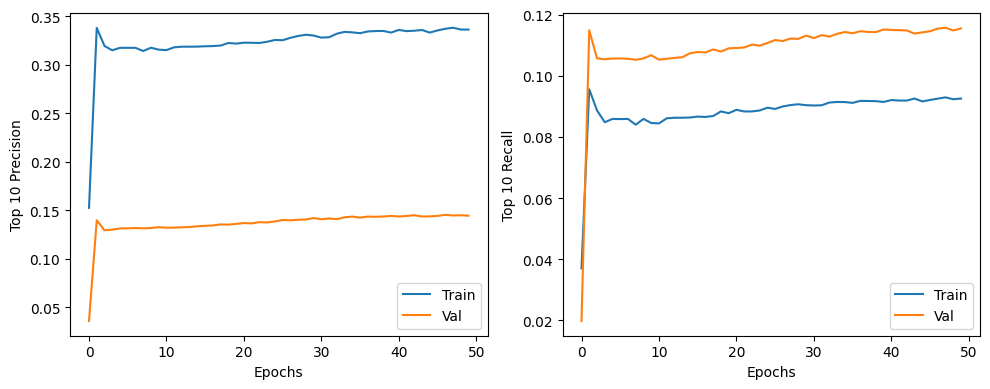

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_tracked, [p for p, _ in train_topks], label="Train")
plt.plot(epochs_tracked, [p for p, _ in val_topks], label="Val")
plt.ylabel(f"Top {config_dict['K']} Precision")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_tracked, [r for _, r in train_topks], label="Train")
plt.plot(epochs_tracked, [r for _, r in val_topks], label="Val")
plt.ylabel(f"Top {config_dict['K']} Recall")
plt.xlabel("Epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
model.eval()
print(f"Training completed after {config_dict['epochs']} epochs")

with torch.no_grad():
    all_users = torch.arange(n_users, device=device)

    test_pred = getUsersRating(model, all_users)
    test_gt = data["edge_index"] * test_mask

    seen_mask_for_test = ((train_mask + val_mask) > 0).float()

    test_p, test_r = compute_metrics(
        test_pred,
        test_gt,
        train_seen_mask=seen_mask_for_test,
        K=config_dict["K"]
    )

    if len(samples_test) > 0:
        loss_test, reg_loss_test = bpr_loss(
            model,
            samples_test[:, 0],
            samples_test[:, 1],
            samples_test[:, 2]
        )
        reg_loss_test = reg_loss_test * config_dict["weight_decay"]
        test_total_loss = (loss_test + reg_loss_test).item()
        test_reg_loss = reg_loss_test.item()
    else:
        test_total_loss = 0.0
        test_reg_loss = 0.0

print(
    f"Test Loss={test_total_loss:.6f} | "
    f"Reg={test_reg_loss:.6f} | "
    f"Top {config_dict['K']} P={test_p:.4f} R={test_r:.4f}"
)

Training completed after 50 epochs
Test Loss=0.575137 | Reg=0.165163 | Top 10 P=0.1784 R=0.1353


In [16]:
result = {
    "config": {
        "dataset_name": config_dict["dataset_name"],
        "num_layers": config_dict["num_layers"],
        "num_samples_per_user": config_dict["num_samples_per_user"],
        "num_users": config_dict["num_users"],
        "batch_size": config_dict["batch_size"],
        "embedding_size": config_dict["embedding_size"],
        "K": config_dict["K"],
        "epochs": config_dict["epochs"],
        "lr": config_dict["lr"],
        "weight_decay": config_dict["weight_decay"],
        "val_frac": config_dict["val_frac"],
        "test_frac": config_dict["test_frac"],
        "seed": config_dict["seed"]
    },
    "train_val_result": {
        "epochs_tracked": epochs_tracked,
        "train_topks": train_topks,
        "val_topks": val_topks
    },
    "test_result": {
        "BPR_loss": test_total_loss,
        "Reg_loss": test_reg_loss,
        "test_topks": {
            "test_p": test_p,
            "test_r": test_r
        }
    },
    "timing": {
        "total_training_time_seconds": total_training_time,
        "propagation_time_seconds": total_prop_time,
        "bpr_objective_time_seconds": total_bpr_objective_time,
        "bprforward_total_time_seconds": total_bpr_forward_time,
        "backward_step_time_seconds": total_step_time,
        "evaluation_time_seconds": total_eval_time,
        "average_epoch_time_seconds": float(np.mean(epoch_times))
    },
    "complexity": {
        "U": U,
        "I": I,
        "R_train": R_train_edges,
        "k": k,
        "L": L,
        "d": d,
        "training_complexity": "O(L|R|d + k|U|d)",
        "space_complexity": "O((|U| + |I|)d + |R|)"
    },
    "model": model.state_dict()
}

torch.save(result, output_file_name)
print(f"Saved to: {output_file_name}")

Saved to: log/result_movielens100k_2layers_50sample_allusers.pkl


## Total Cost Computation


BPR forward total time = Propagation time + BPR objective time

Total Complexity = $O(L|R|d+k|U|d)$

1. How BPR forward time relates to total training time
Training step per batch contains:

Forward pass \
    ├─ propagation \
    ├─ BPR scoring \
Backward pass \
Optimizer step

Actual training computation is "Forward" + "Backward"

2. Add evaluation time

3. Total training time = Forward + Backward + Evaluation

4. Average epoch time is computed as $\text{Average epoch time} = \frac{\text{Total training time}}{\text{Number of epoches}}$

In [17]:
print(f"Propagation time = {total_prop_time:.2f}")
print(f"BPR objective time = {total_bpr_objective_time:.2f}")
print("-"*40)
print(f"Propagation time + BPR objective time = {(total_prop_time+total_bpr_objective_time):.2f}")
print(f"Forward time = {total_bpr_forward_time:.2f}")
print("-"*40)
print(f"Forward time = {total_bpr_forward_time:.2f}")
print(f"Backward time = {total_step_time:.2f}")
print(f"Evaluation = {total_eval_time:.2f}")
print("-"*40)
print(f"Forward pass + Backward pass + Evaluation = {(total_bpr_forward_time + total_step_time + total_eval_time):.2f}")
print(f"Total runtime = {total_training_time:.2f}")

Propagation time = 2.96
BPR objective time = 4.50
----------------------------------------
Propagation time + BPR objective time = 7.46
Forward time = 7.46
----------------------------------------
Forward time = 7.46
Backward time = 24.46
Evaluation = 30.74
----------------------------------------
Forward pass + Backward pass + Evaluation = 62.66
Total runtime = 64.80


In [18]:
# result_ = torch.load(output_file_name)

In [19]:
# result_.keys()
# result_['timing']
# result_['train_val_result']['epochs_tracked']
# result_['config']

In [20]:
# plt.figure(figsize=(10, 4))

# plt.subplot(1, 2, 1)
# plt.plot(result_['train_val_result']['epochs_tracked'], [p for p, _ in result_['train_val_result']['train_topks']], label="Train")
# plt.plot(result_['train_val_result']['epochs_tracked'], [p for p, _ in result_['train_val_result']['val_topks']], label="Val")
# plt.ylabel(f"Top {result_['config']['K']} Precision")
# plt.xlabel("Epochs")
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(result_['train_val_result']['epochs_tracked'], [r for _, r in result_['train_val_result']['train_topks']], label="Train")
# plt.plot(result_['train_val_result']['epochs_tracked'], [r for _, r in result_['train_val_result']['val_topks']], label="Val")
# plt.ylabel(f"Top {result_['config']['K']} Recall")
# plt.xlabel("Epochs")
# plt.legend()

# plt.tight_layout()
# plt.show()

In [21]:
# total_prop_time = result_['timing']['propagation_time_seconds']
# total_bpr_objective_time = result_['timing']['bpr_objective_time_seconds']
# total_bpr_forward_time = result_['timing']['bprforward_total_time_seconds']
# total_step_time = result_['timing']['backward_step_time_seconds']
# total_eval_time = result_['timing']['evaluation_time_seconds']
# total_training_time = result_['timing']['total_training_time_seconds']

# print(f"Propagation time = {total_prop_time:.2f}")
# print(f"BPR objective time = {total_bpr_objective_time:.2f}")
# print("-"*40)
# print(f"Propagation time + BPR objective time = {(total_prop_time+total_bpr_objective_time):.2f}")
# print(f"Forward time = {total_bpr_forward_time:.2f}")
# print("-"*40)
# print(f"Forward time = {total_bpr_forward_time:.2f}")
# print(f"Backward time = {total_step_time:.2f}")
# print(f"Evaluation = {total_eval_time:.2f}")
# print("-"*40)
# print(f"Forward pass + Backward pass + Evaluation = {(total_bpr_forward_time + total_step_time + total_eval_time):.2f}")
# print(f"Total runtime = {total_training_time:.2f}")